# Self-attention calculation (copy-paste into a Jupyter notebook Markdown cell)

**Given**

$$
X=\begin{bmatrix}1 & 0 & 2\\[4pt] 2 & 1 & 1\end{bmatrix},\qquad
W^Q=\begin{bmatrix}1&0\\[2pt]0&1\\[2pt]1&0\end{bmatrix},\qquad
W^K=\begin{bmatrix}0&1\\[2pt]1&0\\[2pt]1&0\end{bmatrix},\qquad
W^V=\begin{bmatrix}1&1\\[2pt]0&1\\[2pt]1&0\end{bmatrix}
$$

**Step 1 — compute queries, keys, values**

$$
Q=XW^Q=\begin{bmatrix}3&0\\[4pt]3&1\end{bmatrix},\qquad
K=XW^K=\begin{bmatrix}2&1\\[4pt]2&2\end{bmatrix},\qquad
V=XW^V=\begin{bmatrix}3&1\\[4pt]3&3\end{bmatrix}
$$

**Step 2 — scaled dot-product scores**

Let $d_k=2$. Compute the (unnormalized) score matrix $S=QK^\top$ and scaled scores $S_{\text{scaled}}=S/\sqrt{d_k}$:

$$
S=QK^\top=\begin{bmatrix}6&6\\[4pt]7&8\end{bmatrix},\qquad
S_{\text{scaled}}=\frac{1}{\sqrt{2}}S \approx
\begin{bmatrix}4.242641 & 4.242641\\[4pt]4.949747 & 5.656854\end{bmatrix}
$$

**Step 3 — softmax over each row (attention weights)**

Apply softmax rowwise to $S_{\text{scaled}}$:

$$
A=\operatorname{softmax}(S_{\text{scaled}})=
\begin{bmatrix}
0.5 & 0.5\\[4pt]
0.33023845 & 0.66976155
\end{bmatrix}
$$

**Step 4 — attention output**

$$
\text{Output}=A\,V=
\begin{bmatrix}
0.5 & 0.5\\[4pt]
0.33023845 & 0.66976155
\end{bmatrix}
\begin{bmatrix}3&1\\[4pt]3&3\end{bmatrix}
=
\begin{bmatrix}
3.000000 & 2.000000\\[4pt]
3.000000 & 2.339523
\end{bmatrix}
$$

**Final result (attention output matrix):**

$$
\boxed{\; \text{Output}=\begin{bmatrix}3 & 2\\[4pt]3 & 2.339523\end{bmatrix}\;}
$$





**Imaging Data Description**

All BraTS multimodal scans are available as NIfTI files (.nii.gz) and describe a) native (T1) and b) post-contrast T1-weighted (T1Gd), c) T2-weighted (T2), and d) T2 Fluid Attenuated Inversion Recovery (T2-FLAIR) volumes, and were acquired with different clinical protocols and various scanners from multiple (n=19) institutions, mentioned as data contributors here.

All the imaging datasets have been segmented manually, by one to four raters, following the same annotation protocol, and their annotations were approved by experienced neuro-radiologists. Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edema (ED — label 2), and the necrotic and non-enhancing tumor core (NCR/NET — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper. The provided data are distributed after their pre-processing, i.e., co-registered to the same anatomical template, interpolated to the same resolution (1 mm^3) and skull-stripped.


### <a id='toc1_3_3_'></a>[U-Net Model](#toc0_)

**U-Net** is a fully convolutional neural network originally designed for semantic image segmentation of biomedical images. This network features a distinctive encoder-decoder structure, making it exceptionally effective for detailed and precise image analysis tasks in the medical field. Since its inception, U-Net has been widely recognized for its robust performance in segmenting complex anatomical structures in medical scans, such as MRIs and CT images.

The architecture of U-Net is particularly notable for its ability to capture contextual information at various scales, which is crucial for accurate segmentation. The encoder part of the network progressively reduces the spatial dimension of the image, capturing high-level semantic information. Conversely, the decoder part gradually recovers object details and spatial dimensions, ensuring precise localization.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Kk-yKGkvRtkNzLkZdP3Pag/unet.png" width="70%" alt="indexing"/>

**Reference:**
1. Original Paper: [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://arxiv.org/abs/1505.04597)

In [12]:
# ============================ IMPORTS ================================
import os
import glob
import random
import gc
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import zipfile
import shutil

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms as T
from tqdm.notebook import tqdm

In [13]:
!git clone https://github.com/Ehsanacc/iMIAP.git

fatal: destination path 'iMIAP' already exists and is not an empty directory.


In [14]:
# Define paths
ZIP_PATH = '/kaggle/working/iMIAP/Assignment 2/train_data/train_data.zip'
EXTRACT_DIR = '/kaggle/working/iMIAP/Assignment 2/train_data/'

# Ensure the extraction directory exists
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Unzip the file
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"Successfully extracted {ZIP_PATH} to {EXTRACT_DIR}")
except zipfile.BadZipFile:
    print(f"Error: {ZIP_PATH} is not a valid zip file.")
except FileNotFoundError:
    print(f"Error: {ZIP_PATH} not found.")
except Exception as e:
    print(f"Error during extraction: {str(e)}")

# Update DATA_ROOT to point to the unzipped directory
DATA_ROOT = EXTRACT_DIR

# Verify the extracted directory contains patient folders
patient_dirs = [os.path.join(DATA_ROOT, d) for d in os.listdir(DATA_ROOT) 
                if os.path.isdir(os.path.join(DATA_ROOT, d))]
if patient_dirs:
    print(f"Found {len(patient_dirs)} patient directories in {DATA_ROOT}")
else:
    print(f"Warning: No patient directories found in {EXTRACT_DIR}")

Successfully extracted /kaggle/working/iMIAP/Assignment 2/train_data/train_data.zip to /kaggle/working/iMIAP/Assignment 2/train_data/
Found 354 patient directories in /kaggle/working/iMIAP/Assignment 2/train_data/


## Prepare Dataset

In [15]:
# ======================= CONFIGURATION CONSTANTS =====================
# NOTE: Adjust DATA_ROOT to your specific path where the BraTS data is located.
DATA_ROOT   = '/kaggle/working/iMIAP/Assignment 2/train_data/'
MODALITIES = ('flair', 't1', 't1ce', 't2')
IMG_SIZE = (128, 128)  # Reduced size for faster training and less memory
BATCH_SIZE = 8       # Increased batch size as image size is smaller
VAL_SPLIT = 0.20
SEED = 42
LEARNING_RATE = 1e-4
NUM_EPOCHS = 25
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device is: {DEVICE}')

# ========================= HELPER FUNCTIONS ==========================
def get_patient_dirs(root: str):
    """Return list of patient folders that contain a segmentation file."""
    patients = [os.path.join(root, d) for d in os.listdir(root)
                if os.path.isdir(os.path.join(root, d))]
    return [p for p in patients if glob.glob(os.path.join(p, '*seg.nii*'))]

def collect_samples(patients, modalities=MODALITIES):
    """Return list of (patient_dir, modality) tuples where the image exists."""
    samples = []
    for p in patients:
        for m in modalities:
            if glob.glob(os.path.join(p, f'*{m}.nii*')):
                samples.append((p, m))
    return samples

def slice_from_nifti(path, z):
    """Memory-mapped read of axial slice z from a .nii(.gz) file."""
    proxy = nib.load(path, mmap=True).dataobj
    slice2d = np.asanyarray(proxy[..., z], dtype=np.float32)
    return slice2d

def get_transforms(train=True):
    """Get transformations for training and validation sets."""
    common = [T.Resize(IMG_SIZE, antialias=True)]
    aug = [T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(15)]
    return T.Compose(common + (aug if train else []))


# ============================= DATASET ===============================
class BraTSDataset(Dataset):
    """
    Yields (1, H, W) image & binary mask tensors in [0, 1].
    Uses lazy mem-mapped slice loading for minimal RAM usage.
    """
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patient_dir, modality = self.samples[idx]
        img_path = glob.glob(os.path.join(patient_dir, f'*{modality}.nii*'))[0]
        seg_path = glob.glob(os.path.join(patient_dir, '*seg.nii*'))[0]

        # Use center slice for simplicity
        z = nib.load(img_path).shape[-1] // 2

        img = slice_from_nifti(img_path, z)
        mask = slice_from_nifti(seg_path, z)
        mask = (mask > 0).astype(np.float32)

        # Robust [0, 1] normalization
        img_min, img_max = img.min(), img.max()
        img_range = img_max - img_min
        img = (img - img_min) / (img_range + 1e-8) if img_range > 0 else np.zeros_like(img)

        # Convert to torch tensors (C, H, W)
        img = torch.from_numpy(img).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        # Apply identical transform to both image and mask
        if self.transform:
            seed = random.randint(0, 2**32 - 1)
            torch.manual_seed(seed)
            img = self.transform(img)
            torch.manual_seed(seed)
            mask = self.transform(mask)

        return img, mask

Device is: cuda


## Construct Models
Let's construct a U-Net model for the dataset.

Now we augment the regular UNet with several sub-modules and techniques such as ResNets, Attention modules, etc. We describe the expected architecture for this notebook:

+ *ResNet:* As a base sub-module, we define each ResNet block as two consecutive convolutional layers with a GELU activation in between and Group Normalization after each convolutional layer. You can use this module in Down/Up blocks. Also, by removing the residual connection, you can use this block as a convolutional network throughout the network.
+ *Attention:* This is also a sub-module consisting of a Layer Normalization, Multi-head Attention (use from `torch.nn`), a residual connection, a feed-forward network, and another residual connection.

You can implement the following structure for UNet:

+ Convolutional block
+ Down block
+ Attention
+ Down block
+ Attention
+ Down block
+ Attention

+ Convolutional block (bottleneck)
+ Convolutional block (bottleneck)
+ Convolutional block (bottleneck)

+ Up block
+ Attention
+ Up block
+ Attention
+ Up block
+ Attention
+ Convolutional block

In [16]:

# ======================== DATA PIPELINE BUILDER ======================
def build_dataloaders():
    """Builds and returns training and validation dataloaders."""
    patients = get_patient_dirs(DATA_ROOT)
    samples = collect_samples(patients)
    print(f'Total Patients: {len(patients)} | Total Samples (slices): {len(samples)}')

    train_s, val_s = train_test_split(samples, test_size=VAL_SPLIT, random_state=SEED, shuffle=True)

    train_set = BraTSDataset(train_s, get_transforms(train=True))
    val_set = BraTSDataset(val_s, get_transforms(train=False))

    dl_kwargs = {'batch_size': BATCH_SIZE, 'num_workers': 2, 'pin_memory': True}
    train_dl = DataLoader(train_set, shuffle=True, **dl_kwargs)
    val_dl = DataLoader(val_set, shuffle=False, **dl_kwargs)

    print(f'Train batches: {len(train_dl)} | Validation batches: {len(val_dl)}')
    return train_dl, val_dl

# ============================ UNET MODELS ============================
# --- Building Blocks ---
def double_conv_bn(in_channels, out_channels):
    """(Convolution -> BatchNorm -> ReLU) * 2"""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

class AttentionGate(nn.Module):
    """Attention Gate (AG) for the UNet-Attention model."""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

# --- Standard UNet ---
class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1):
        super().__init__()
        self.encoder1 = double_conv_bn(n_channels, 64)
        self.encoder2 = double_conv_bn(64, 128)
        self.encoder3 = double_conv_bn(128, 256)
        self.encoder4 = double_conv_bn(256, 512)
        self.bottleneck = double_conv_bn(512, 1024)
        self.pool = nn.MaxPool2d(2, 2)

        self.up_trans1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder1 = double_conv_bn(1024, 512)
        self.up_trans2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder2 = double_conv_bn(512, 256)
        self.up_trans3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder3 = double_conv_bn(256, 128)
        self.up_trans4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder4 = double_conv_bn(128, 64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.encoder1(x)
        x2 = self.encoder2(self.pool(x1))
        x3 = self.encoder3(self.pool(x2))
        x4 = self.encoder4(self.pool(x3))
        bottleneck = self.bottleneck(self.pool(x4))

        # Decoder
        u1 = self.up_trans1(bottleneck)
        d1 = torch.cat([u1, x4], dim=1)
        d1 = self.decoder1(d1)

        u2 = self.up_trans2(d1)
        d2 = torch.cat([u2, x3], dim=1)
        d2 = self.decoder2(d2)

        u3 = self.up_trans3(d2)
        d3 = torch.cat([u3, x2], dim=1)
        d3 = self.decoder3(d3)

        u4 = self.up_trans4(d3)
        d4 = torch.cat([u4, x1], dim=1)
        d4 = self.decoder4(d4)

        return self.out_conv(d4)

# --- UNet with Attention ---
class UNetAttention(nn.Module):
    def __init__(self, n_channels=1, n_classes=1):
        super().__init__()
        self.encoder1 = double_conv_bn(n_channels, 64)
        self.encoder2 = double_conv_bn(64, 128)
        self.encoder3 = double_conv_bn(128, 256)
        self.encoder4 = double_conv_bn(256, 512)
        self.bottleneck = double_conv_bn(512, 1024)
        self.pool = nn.MaxPool2d(2, 2)

        self.up_trans1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.decoder1 = double_conv_bn(1024, 512)

        self.up_trans2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.decoder2 = double_conv_bn(512, 256)

        self.up_trans3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.decoder3 = double_conv_bn(256, 128)

        self.up_trans4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att4 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.decoder4 = double_conv_bn(128, 64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.encoder1(x)
        x2 = self.encoder2(self.pool(x1))
        x3 = self.encoder3(self.pool(x2))
        x4 = self.encoder4(self.pool(x3))
        bottleneck = self.bottleneck(self.pool(x4))

        # Decoder with Attention
        u1 = self.up_trans1(bottleneck)
        x4_att = self.att1(g=u1, x=x4)
        d1 = torch.cat([u1, x4_att], dim=1)
        d1 = self.decoder1(d1)

        u2 = self.up_trans2(d1)
        x3_att = self.att2(g=u2, x=x3)
        d2 = torch.cat([u2, x3_att], dim=1)
        d2 = self.decoder2(d2)

        u3 = self.up_trans3(d2)
        x2_att = self.att3(g=u3, x=x2)
        d3 = torch.cat([u3, x2_att], dim=1)
        d3 = self.decoder3(d3)

        u4 = self.up_trans4(d3)
        x1_att = self.att4(g=u4, x=x1)
        d4 = torch.cat([u4, x1_att], dim=1)
        d4 = self.decoder4(d4)

        return self.out_conv(d4)

## Define Loss Functions

In [17]:
# ========================== LOSS FUNCTIONS ===========================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth)
        return (1 - dice_score).mean()

class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        bce = self.bce_loss(logits, targets)
        return self.dice_weight * dice + self.bce_weight * bce

## Train and Eval

In [18]:
# ======================= TRAINING & EVALUATION =======================
@torch.inference_mode()
def dice_accuracy(logits, targets, threshold=0.5):
    """Computes mean Dice coefficient over a mini-batch."""
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2. * intersection + 1e-8) / (union + 1e-8)
    return dice.mean().item()

def run_training(model, criterion, train_loader, val_loader, num_epochs, tag):
    # print('hi1')
    """Main training loop."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    main_pbar = tqdm(range(num_epochs), desc=f'Training Run: {tag.upper()}')
    model.train()
    # print('hi2')
    for epoch in main_pbar:
        # --- Training ---
        train_loss, train_acc = 0.0, 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            # print('hi3')
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += dice_accuracy(logits, masks)

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # --- Validation ---
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                logits = model(imgs)
                val_loss += criterion(logits, masks).item()
                val_acc += dice_accuracy(logits, masks)

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        main_pbar.set_postfix(
            Train_Loss=f"{train_loss:.4f}", Val_Loss=f"{val_loss:.4f}",
            Train_Acc=f"{train_acc:.4f}", Val_Acc=f"{val_acc:.4f}"
        )
    return history

## Visualization

In [19]:
# =========================== VISUALIZATION ===========================
def plot_history(histories):
    """Plots loss and accuracy curves for all training runs."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Loss
    for name, hist in histories.items():
        axes[0].plot(hist['train_loss'], label=f'{name} Train')
        axes[0].plot(hist['val_loss'], '--', label=f'{name} Val')
    axes[0].set_title('Model Loss', fontsize=16)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot Accuracy
    for name, hist in histories.items():
        axes[1].plot(hist['train_acc'], label=f'{name} Train')
        axes[1].plot(hist['val_acc'], '--', label=f'{name} Val')
    axes[1].set_title('Model Dice Accuracy', fontsize=16)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Dice Coefficient')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# ============================ MAIN EXECUTION =========================

# Set seed for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 1. Build DataLoaders
train_loader, val_loader = build_dataloaders()

# 2. Define Loss Functions and Models to Test
loss_fns = {
    'BCE': nn.BCEWithLogitsLoss(),
    'Dice': DiceLoss(),
    'DiceBCE': DiceBCELoss()
}

all_histories = {}

# 3. Train Standard UNet with different loss functions
for tag, criterion in loss_fns.items():
    print(f"\n--- Starting UNet training with {tag} loss ---")
    unet_model = UNet(n_channels=1, n_classes=1)
    history = run_training(unet_model, criterion, train_loader, val_loader, NUM_EPOCHS, f"UNet-{tag}")
    all_histories[f"UNet-{tag}"] = history
    del unet_model
    gc.collect()
    torch.cuda.empty_cache()


Total Patients: 354 | Total Samples (slices): 1416
Train batches: 142 | Validation batches: 36

--- Starting UNet training with BCE loss ---


Training Run: UNET-BCE:   0%|          | 0/25 [00:00<?, ?it/s]


--- Starting UNet training with Dice loss ---


Training Run: UNET-DICE:   0%|          | 0/25 [00:00<?, ?it/s]


--- Starting UNet training with DiceBCE loss ---


Training Run: UNET-DICEBCE:   0%|          | 0/25 [00:00<?, ?it/s]

In [20]:
# 4. Train UNet-Attention model with BCE loss
best_loss_tag = 'BCE'
print(f"\n--- Starting UNet-Attention training with {best_loss_tag} loss ---")
attention_model = UNetAttention(n_channels=1, n_classes=1)
history = run_training(attention_model, loss_fns[best_loss_tag], train_loader, val_loader, NUM_EPOCHS, f"UNetAttention-{best_loss_tag}")
all_histories[f"UNetAttention-{best_loss_tag}"] = history
del attention_model
gc.collect()
torch.cuda.empty_cache()


--- Starting UNet-Attention training with BCE loss ---


Training Run: UNETATTENTION-BCE:   0%|          | 0/25 [00:00<?, ?it/s]

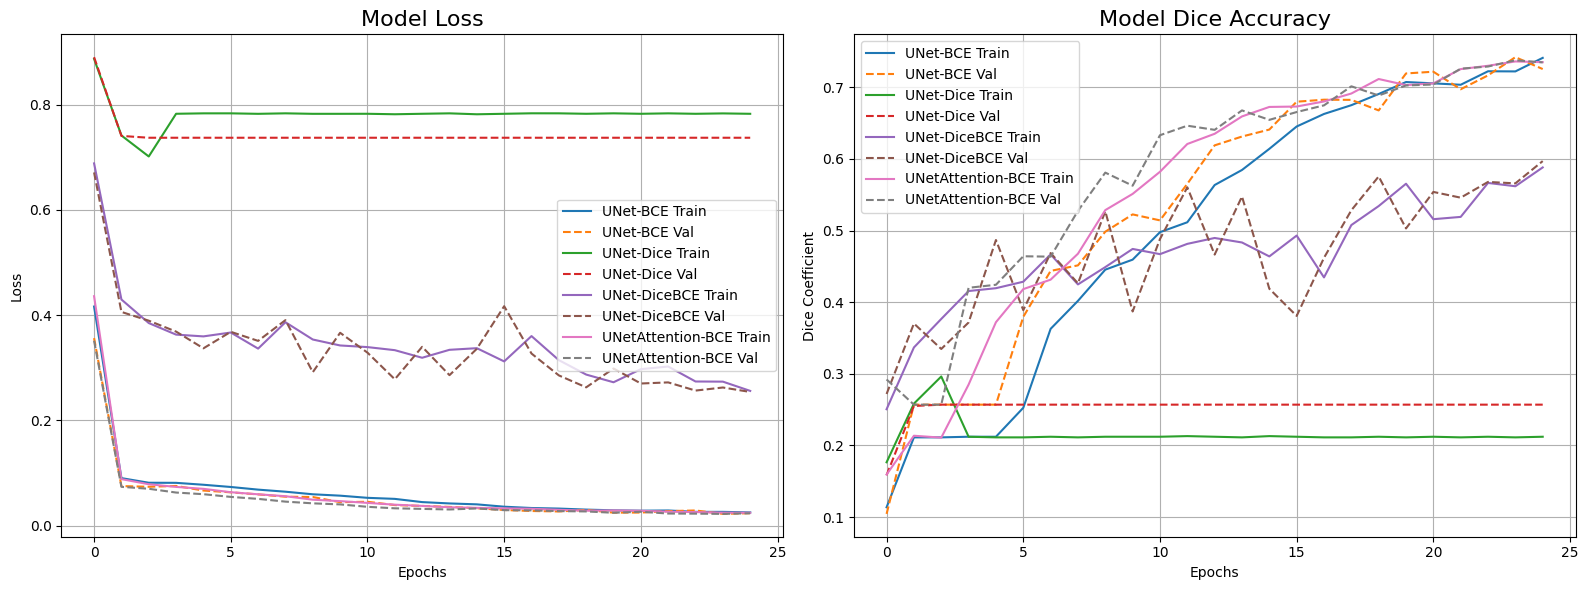

In [21]:
# 5. Plot all results
plot_history(all_histories)